In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [ ]:
df = pd.read_csv('creditcard.csv')

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [ ]:
df.shape

(77338, 31)

In [ ]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [ ]:
df['Class'].value_counts()

,count
Class,
0.0,77149
1.0,188


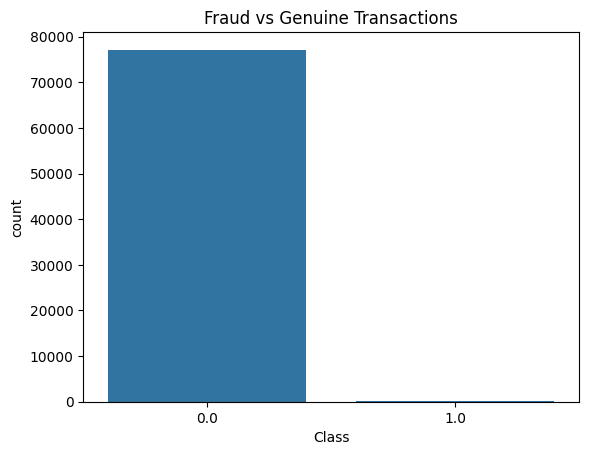

In [ ]:
sns.countplot(x='Class', data=df)
plt.title("Fraud vs Genuine Transactions")
plt.show()

Feature Scaling

In [ ]:
scaler = StandardScaler()

df['Amount'] = scaler.fit_transform(df[['Amount']])

In [ ]:
df = df.drop('Time', axis=1)

Split Features and Target

In [ ]:
X = df.drop('Class', axis=1)

y = df['Class']

Handle Imbalanced Data

In [ ]:
fraud = df[df['Class'] == 1]

genuine = df[df['Class'] == 0]

In [ ]:
genuine_sample = genuine.sample(n=492, random_state=42)

new_df = pd.concat([genuine_sample, fraud], axis=0)

new_df['Class'].value_counts()

,count
Class,
0.0,492
1.0,188


Prepare Balanced Dataset

In [ ]:
X = new_df.drop('Class', axis=1)

y = new_df['Class']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Train Logistic Regression

In [ ]:
model = LogisticRegression()

model.fit(X_train, y_train)

LogisticRegression()

Prediction

In [ ]:
y_pred = model.predict(X_test)

Evaluation

In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9632352941176471


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.97      0.98      0.98       106
         1.0       0.93      0.90      0.92        30

    accuracy                           0.96       136
   macro avg       0.95      0.94      0.95       136
weighted avg       0.96      0.96      0.96       136



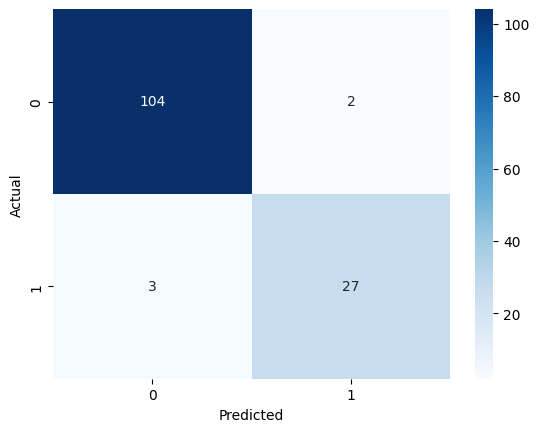

In [ ]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Try Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()

dt.fit(X_train, y_train)

pred = dt.predict(X_test)

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

         0.0       0.97      0.95      0.96       106
         1.0       0.84      0.90      0.87        30

    accuracy                           0.94       136
   macro avg       0.91      0.93      0.92       136
weighted avg       0.94      0.94      0.94       136



Advanced Version

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

pred = rf.predict(X_test)

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

         0.0       0.97      1.00      0.99       106
         1.0       1.00      0.90      0.95        30

    accuracy                           0.98       136
   macro avg       0.99      0.95      0.97       136
weighted avg       0.98      0.98      0.98       136

